# Charte graphique

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">1. Section principale</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.1 Sous-section</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">1.1.1 Sous-sous-section</p>

##### <p style="background-color:#b8d1e2;color:black; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">1.1.1.x.x.x. Toutes les autres sous-section</p>

# <p style="background: linear-gradient(90deg, #1A5276, #2980B9); color:#FFFFFF; padding:30px; border-radius:10px; text-align:center;"><span style="font-size:34px; font-weight:bold;">Identifiez les causes d'attrition au sein de l'ESN TechNova Partners</span><br></p>

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">0. Import</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">0.1 Import librairie</p>

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">0.2 - Import des DataSet</p>

In [2]:
eval = pd.read_csv("data/extrait_eval.csv")
sirh = pd.read_csv("data/extrait_sirh.csv")
sondage = pd.read_csv("data/extrait_sondage.csv")

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">1. - DataSet extrait_eval.csv</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.1 - Analyse préliminaire</p>

In [3]:
eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB


Toutes les valeur sont remplies aucune vide

In [4]:
eval.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
satisfaction_employee_nature_travail,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
satisfaction_employee_equipe,1470.0,2.712245,1.081209,1.0,2.0,3.0,4.0,4.0
satisfaction_employee_equilibre_pro_perso,1470.0,2.761224,0.706476,1.0,2.0,3.0,3.0,4.0
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.0,3.0,3.0,3.0,4.0


In [5]:
eval.head(2)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %


In [6]:
for col in eval.columns:
    print(f" {col} : {eval[col].unique()}\n============================")

 satisfaction_employee_environnement : [2 3 4 1]
 note_evaluation_precedente : [3 2 4 1]
 niveau_hierarchique_poste : [2 1 3 4 5]
 satisfaction_employee_nature_travail : [4 2 3 1]
 satisfaction_employee_equipe : [1 4 2 3]
 satisfaction_employee_equilibre_pro_perso : [1 3 2 4]
 eval_number : <StringArray>
[   'E_1',    'E_2',    'E_4',    'E_5',    'E_7',    'E_8',   'E_10',
   'E_11',   'E_12',   'E_13',
 ...
 'E_2054', 'E_2055', 'E_2056', 'E_2057', 'E_2060', 'E_2061', 'E_2062',
 'E_2064', 'E_2065', 'E_2068']
Length: 1470, dtype: str
 note_evaluation_actuelle : [3 4]
 heure_supplementaires : <StringArray>
['Oui', 'Non']
Length: 2, dtype: str
 augementation_salaire_precedente : <StringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str


##### <p style="background-color:#b8d1e2;color:black; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">1.2.1 - Tableaux des variables</p>

| Variable| Descritpion | A garder ? |valeur type |
|:-------|:------|:-------:|-------:  |
| satisfaction_employee_environnement|Note de satisfaction sur l'environement|oui|1 à 4|
| note_evaluation_precedente     |Peut être la note donné par le responssable|  non |1 à 4  |
| niveau_hierarchique_poste     |Peut être le niveau de hierachie du poste| oui  | 1 à 5 |
| satisfaction_employee_nature_travail     |Note donné pour jugé si ce qu'il fait lui plait| oui  |1 à 4|
| satisfaction_employee_equipe      |Note pour la relation equipe| oui|1 à 4  |
| satisfaction_employee_equilibre_pro_perso      |Note pour l'mpietement du pro sur le perso| oui |1 à 4|
| eval_number      |Numéro de l'employer | oui |E_1 / E_2/E_2068  |
| note_evaluation_actuelle     |idem note precedente  |non| 3 ou 4|
| heure_supplementaires     | S'il fait des heures sup  |oui       |oui / non |
| augementation_salaire_precedente     |Valeur de l'augementation|oui  |en % (string)     |

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.2 - Répartition des notes</p>

In [7]:
# apply value_counts() sur chaque colonne séparément
df_counts = eval[['satisfaction_employee_environnement','satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso']].apply(pd.Series.value_counts)
df_counts

,satisfaction_employee_environnement,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso
1,284,289,276,80
2,287,280,303,344
3,453,442,459,893
4,446,459,432,153


In [8]:
fig = px.bar(df_counts, barmode="group")
fig.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.3 - Recupération de l'id employé</p>

In [9]:
eval["id_employee"] = eval.eval_number.str.split("_").str[-1].astype("int64")
eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,id_employee
0,2,3,2,4,1,1,E_1,3,Oui,11 %,1
1,3,2,2,2,4,3,E_2,4,Non,23 %,2
2,4,2,1,3,2,3,E_4,3,Oui,15 %,4
3,4,3,1,3,3,3,E_5,3,Oui,11 %,5
4,1,3,1,2,4,3,E_7,3,Non,12 %,7


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.4 - Modification de augmentation de salaire en numérique</p>

In [10]:
eval.augementation_salaire_precedente = eval.augementation_salaire_precedente.str.split(" ").str[0].astype("int64")

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">1.5 - Supression des colonne inutile</p>

In [11]:
eval_clean = eval.drop(columns=["note_evaluation_precedente","eval_number","note_evaluation_actuelle"])

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">2. - DataSet extrait_sirh.csv</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">2.1 - Analyse préliminaire</p>

In [12]:
sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 137.9 KB


In [13]:
sirh.describe().T

,count,mean,std,min,25%,50%,75%,max
id_employee,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0
nombre_heures_travailless,1470.0,80.000000,0.000000,80.0,80.00,80.0,80.00,80.0
annee_experience_totale,1470.0,11.279592,7.780782,0.0,6.00,10.0,15.00,40.0
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.0,7.00,18.0


In [14]:
sirh.head(2)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7


In [15]:
for col in sirh.columns:
    print(f" {col} : {sirh[col].unique()}\n============================")

 id_employee : [   1    2    4 ... 2064 2065 2068]
 age : [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
 genre : <StringArray>
['F', 'M']
Length: 2, dtype: str
 revenu_mensuel : [5993 5130 2090 ... 9991 5390 4404]
 statut_marital : <StringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str
 departement : <StringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str
 poste : <StringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str
 nombre_experiences_precedentes : [8 1 6 9 0 4 5 2 7 3]
 nombre_heures_travailless : [80]
 annee_experience_totale : [ 8 10  7  6 12  1 17  5  3 31 13  0 26 24 22  9 19  2 23 14 15  4 29 28
 21 25 20 11 16 37

##### <p style="background-color:#b8d1e2;color:black; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">2.1.1 - Tableaux des variables</p>

| Variable| Descritpion | A garder ? |valeur type |
|:-------|:------|:-------:|-------:  |
|   id_employee    | numero employer pour la fusion des df |     oui  |    numéro   |
|  age   |       |     oui  |       |
|   genre  |       |     oui  |       |
|  revenu_mensuel   |probablement le coût total du salarié|     oui  |       |
|  statut_marital   |       |     oui  |  Célibataire, Marié(e), Divorcé(e)     |
|  departement   |       |     oui  | Commercial, Consulting, Ressources Humaines      |
|  poste   |       |     oui  |       |
|  nombre_experiences_precedentes   |       |     oui  |  nombres     |
|   annees_dans_l_entreprise  |       |     oui  |   années    |
|  annees_dans_le_poste_actuel   |       |     oui  |     années  |
|   nombre_heures_travailless  |       |     non |   toujours 80    |
|   annee_experience_totale  |       |     non  |    années   |


In [16]:
sirh_clean =  sirh.drop(columns=["nombre_heures_travailless","annee_experience_totale"])

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">3. - DataSet extrait_sondage.csv</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.1 - Analyse préliminaire</p>

In [17]:
sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [18]:
sondage.describe().T

,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.00,1.0,1.00,3.0
nb_formations_suivies,1470.0,2.799320,1.289271,0.0,2.00,3.0,3.00,6.0
nombre_employee_sous_responsabilite,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
code_sondage,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.00,1.0,3.00,15.0
annes_sous_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.00,3.0,7.00,17.0


In [19]:
sondage.head(2)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7


In [20]:
for col in sondage.columns:
    print(f" {col} : {sondage[col].unique()}\n============================")

 a_quitte_l_entreprise : <StringArray>
['Oui', 'Non']
Length: 2, dtype: str
 nombre_participation_pee : [0 1 3 2]
 nb_formations_suivies : [0 3 2 5 1 4 6]
 nombre_employee_sous_responsabilite : [1]
 code_sondage : [   1    2    4 ... 2064 2065 2068]
 distance_domicile_travail : [ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25 12 18 29 22
 14 20 28 17 13]
 niveau_education : [2 1 4 3 5]
 domaine_etude : <StringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str
 ayant_enfants : <StringArray>
['Y']
Length: 1, dtype: str
 frequence_deplacement : <StringArray>
['Occasionnel', 'Frequent', 'Aucun']
Length: 3, dtype: str
 annees_depuis_la_derniere_promotion : [ 0  1  3  2  7  4  8  6  5 15  9 13 12 10 11 14]
 annes_sous_responsable_actuel : [ 5  7  0  2  6  8  3 11 17  1  4 12  9 10 15 13 16 14]


##### <p style="background-color:#b8d1e2;color:black; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">3.1.1 - Tableaux des variables</p>

| Variable| Descritpion | A garder ? |valeur type |
|:-------|:------|:-------:|-------:  |
| a_quitte_l_entreprise|          |oui    | Oui/Non        |
| nombre_participation_pee |Participation Plan d'Épargne Entreprise|oui    |  0,1,2,3    |
|  nb_formations_suivies      |          |oui    |   0,3,2,5,1,4,6     |
|  nombre_employee_sous_responsabilite      |          |non    |   toujours 1      |
|   code_sondage     |les même nombre que les identifiants employé |oui    |  nombres       |
|    distance_domicile_travail    |          |oui    |   km ?      |
|     niveau_education   |          |oui    |  2, 1, 4, 3, 5       |
|     domaine_etude   |          |oui    |         |
|     ayant_enfants   |          |non    |  Tous Y pour yes surement      |
|     frequence_deplacement   |          |oui    | Occasionnel, Frequent, Aucun        |
|     annees_depuis_la_derniere_promotion   |          |oui    |  années       |
|     annes_sous_responsable_actuel   |          |oui    |     années    |


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.2 - Analyse a_quitte_l_entreprise</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">3.2.1 Graph de répartion</p>

Il y a juste marqué s'il ont quitté l'entreprise, pas si il sont partie d'eux même, ni la nature de la rupture (démission, licensiement, Rupture conventionnelle )

In [21]:
df = sondage["a_quitte_l_entreprise"].value_counts().reset_index()
fig = go.Figure(data=[go.Pie(labels=['Non','Oui'],
                             values=df["count"])])
fig.update_traces(hoverinfo='label+percent', textinfo='value+percent', textfont_size=20,
                  )
fig.show()

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">3.2.1 Analyse de ceux qui sont parties</p>

In [22]:
df_demission = sondage[sondage.a_quitte_l_entreprise == "Oui"]
df_demission

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
14,Oui,0,4,1,19,24,3,Infra & Cloud,Y,Occasionnel,0,3
21,Oui,0,4,1,27,9,4,Infra & Cloud,Y,Occasionnel,0,3
24,Oui,0,2,1,31,6,1,Transformation Digitale,Y,Occasionnel,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1438,Oui,1,3,1,2023,9,3,Marketing,Y,Frequent,1,0
1442,Oui,3,3,1,2027,1,4,Transformation Digitale,Y,Occasionnel,2,2
1444,Oui,1,4,1,2032,7,2,Entrepreunariat,Y,Occasionnel,9,8
1452,Oui,2,3,1,2044,1,4,Infra & Cloud,Y,Frequent,0,1


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">3.3 - Supression des colonnes inutiles</p>


In [23]:
sondage_clean = sondage.drop(columns=["nombre_employee_sous_responsabilite", "ayant_enfants"])
#Renomer la colonne code_sondage en id_employee pour le merge
sondage_clean = sondage_clean.rename(columns={"code_sondage":"id_employee"})

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">4. Jointure</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.1 - Jointure</p>

In [24]:
df_merge = pd.merge(sirh_clean, eval_clean, on="id_employee")
df_merge = pd.merge(df_merge, sondage_clean, on="id_employee")
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annees_dans_l_entreprise,annees_dans_le_poste_actuel,...,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,6,4,...,11,Oui,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,7,...,23,Non,1,3,8,1,Infra & Cloud,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,0,0,...,15,Oui,0,3,2,2,Autre,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,7,...,11,Non,0,3,3,4,Infra & Cloud,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,2,2,...,12,Non,1,3,2,1,Transformation Digitale,Occasionnel,2,2


In [25]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 26 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id_employee                                1470 non-null   int64
 1   age                                        1470 non-null   int64
 2   genre                                      1470 non-null   str  
 3   revenu_mensuel                             1470 non-null   int64
 4   statut_marital                             1470 non-null   str  
 5   departement                                1470 non-null   str  
 6   poste                                      1470 non-null   str  
 7   nombre_experiences_precedentes             1470 non-null   int64
 8   annees_dans_l_entreprise                   1470 non-null   int64
 9   annees_dans_le_poste_actuel                1470 non-null   int64
 10  satisfaction_employee_environnement        1470 non-null   

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.2 - Analyse de la jointure</p>

In [26]:
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annees_dans_l_entreprise,annees_dans_le_poste_actuel,...,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,6,4,...,11,Oui,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,7,...,23,Non,1,3,8,1,Infra & Cloud,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,0,0,...,15,Oui,0,3,2,2,Autre,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,7,...,11,Non,0,3,3,4,Infra & Cloud,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,2,2,...,12,Non,1,3,2,1,Transformation Digitale,Occasionnel,2,2


On vois de trés forte corrélation entre certaine variable, certaine sont attendu. 
- niveau_hierachique / revenu_mensuel (0.95 - Attendu)
- annees_dans_le_poste_actuel / annees_dans_l_entreprise (0.76 - Attendu)
- annees_depuis_la_derniere_promotion / annees_dans_l_entreprise (0.62 - moins evident commme corrélation)
- annes_sous_responsable_actuel / annees_dans_le_poste_actuel (0.71 - Attendu)
- annes_sous_responsable_actuel / annees_dans_l_entreprise (0.77 - Attendu)

**annees_dans_l_entreprise** : apparaît 3 fois, peut êtres n'est elle pas nécéssaire si elle peut être trouver par les autre, variable


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">4.1.1 Transformation numérique de certaine variable</p>

In [27]:
df_merge.select_dtypes(include='str').nunique()

genre                    2
statut_marital           3
departement              3
poste                    9
heure_supplementaires    2
a_quitte_l_entreprise    2
domaine_etude            6
frequence_deplacement    3
dtype: int64

In [28]:
#Transformation de genre en M=0 F=1
df_merge.genre = df_merge.genre.apply(lambda x: 0 if x=='M' else 1)
#Transformation de heure_supplementaires en Non=0 Oui=1
df_merge.heure_supplementaires = df_merge.heure_supplementaires.apply(lambda x: 0 if x=='Non' else 1)
#Transformation de a_quitte_l_entreprise Non=0 Oui=1
df_merge.a_quitte_l_entreprise = df_merge.a_quitte_l_entreprise.apply(lambda x: 0 if x=='Non' else 1)


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">4.1.2 - Supression de la colonne id_employee</p>


In [29]:
df_merge = df_merge.drop(columns="id_employee")

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">4.1.3 Analyse de corrélation graphique</p>

In [30]:
#Calculer la matrice de corrélation
corr_matrix = df_merge.corr(numeric_only=True)



# Créer un masque pour cacher le triangle supérieur (garder diagonale + inférieur)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_masked = corr_matrix.mask(mask)  # remplace par NaN les valeurs masquées

fig = px.imshow(
    corr_masked,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    aspect="auto"
)

fig.update_layout(
    width=1000,   # agrandir en largeur
    height=600,  # agrandir en hauteur (carré car matrice carrée)
    xaxis=dict(tickangle=45, dtick=1),  # dtick=1 force l'affichage de CHAQUE label
    yaxis=dict(dtick=1)
)
fig.show()



In [31]:
higt_corr = np.where((corr_masked > 0.7) & (corr_masked < 1))
index, col = higt_corr
for i, col in zip(index, col):
    print(f"{corr_masked.index[i]} / {corr_masked.columns[col]} : {corr_masked.iloc[i,col]}")
index_drop = [corr_masked.index[i] for i in index]
features_drop = np.unique(index_drop)
print("Feature à supprimer : ",features_drop)

annees_dans_le_poste_actuel / annees_dans_l_entreprise : 0.7587537366134619
niveau_hierarchique_poste / revenu_mensuel : 0.9502999134798472
annes_sous_responsable_actuel / annees_dans_l_entreprise : 0.7692124251007031
annes_sous_responsable_actuel / annees_dans_le_poste_actuel : 0.7143647616385931
Feature à supprimer :  ['annees_dans_le_poste_actuel' 'annes_sous_responsable_actuel'
 'niveau_hierarchique_poste']


In [32]:
# Comparaison des 17 variables numériques selon la variable cible

#data frame contenant uniquement les variable numérique et le target 
df = df_merge.select_dtypes(include="int64").copy()

target_column = "a_quitte_l_entreprise"  


numeric_columns = df.columns 
numeric_columns = numeric_columns.drop(target_column)

# --- Séparation des variables selon leur nature ---
# Ordinales à faible cardinalité (échelles de notation, catégories discrètes peu nombreuses)
ordinal_columns = [
    "satisfaction_employee_environnement", "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail", "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso", "nombre_participation_pee",
    "nb_formations_suivies", "niveau_education", "nombre_experiences_precedentes",
    "genre", "heure_supplementaires"
]

# Continues (à traiter en violin, potentiellement avec échelle log)
continuous_columns = [col for col in df.columns if col not in ordinal_columns + [target_column]]

# Colonnes continues fortement skewed à droite -> candidates au log1p
log_scale_columns = [
    "revenu_mensuel", "distance_domicile_travail",
    "annees_dans_l_entreprise", "annees_dans_le_poste_actuel",
    "annees_depuis_la_derniere_promotion", "annes_sous_responsable_actuel",
    "augementation_salaire_precedente"
]

positive_label, negative_label = 0, 1  

n_cols = 3
n_rows = -(-len(numeric_columns) // n_cols)  # ceil division
corrected_alpha = 0.05 / len(numeric_columns)  # correction Bonferroni 
p_values = {}



In [33]:
#Voir quel variable sont skew (asymétrique)
for col in continuous_columns:
    print(f"{col} : {df[col].skew()}")

age : 0.4132863018563338
revenu_mensuel : 1.3698166808390662
annees_dans_l_entreprise : 1.7645294543422085
annees_dans_le_poste_actuel : 0.9173631562908262
augementation_salaire_precedente : 0.8211279755780908
distance_domicile_travail : 0.9581179956568269
annees_depuis_la_derniere_promotion : 1.9842899833524859
annes_sous_responsable_actuel : 0.8334509919918475


- proche de 0 = symétrique, 
- positif = skew droite, 
- négatif = skew gauche 
Au-delà de |skew| > 1, on considère généralement que c'est suffisamment marqué pour justifier une transformation (log1p par exemple)

| Variable | Skew | Décision log1p |
|---|---|---|
| `age` | 0.41 | **Non** — quasi symétrique |
| `revenu_mensuel` | 1.37 | **Oui** — au-dessus du seuil |
| `annees_dans_l_entreprise` | 1.76 | **Oui** — fortement skewed |
| `annees_dans_le_poste_actuel` | 0.92 | **Limite** — juste en dessous du seuil |
| `distance_domicile_travail` | 0.96 | **Limite** — juste en dessous du seuil |
| `annees_depuis_la_derniere_promotion` | 1.98 | **Oui** — la plus skewed de toutes |
| `annes_sous_responsable_actuel` | 0.83 | **Limite/Non** — en dessous du seuil |



In [34]:
#transformation des variable skewed en log1p

df[log_scale_columns] = np.log(df[log_scale_columns]+1)
df.head()

,age,genre,revenu_mensuel,nombre_experiences_precedentes,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,41,1,8.698514,8,1.945910,1.609438,2,2,4,1,1,1,2.484907,1,0,0,0.693147,2,0.000000,1.791759
1,49,0,8.543056,1,2.397895,2.079442,3,2,2,4,3,0,3.178054,0,1,3,2.197225,1,0.693147,2.079442
2,37,0,7.645398,6,0.000000,0.000000,4,1,3,2,3,1,2.772589,1,0,3,1.098612,2,0.000000,0.000000
3,33,1,7.975908,1,2.197225,2.079442,4,1,3,3,3,1,2.484907,0,0,3,1.386294,4,1.386294,0.000000
4,27,0,8.151622,9,1.098612,1.098612,1,1,2,4,3,0,2.564949,0,1,3,1.098612,1,1.098612,1.098612


In [35]:
n_cols = 3
n_rows = -(-len(continuous_columns) // n_cols)

fig_violin = sp.make_subplots(rows=n_rows, cols=n_cols, subplot_titles=continuous_columns)

for idx, col in enumerate(continuous_columns):
    row = idx // n_cols + 1
    col_pos = idx % n_cols + 1

    group_pos = df.loc[df[target_column] == positive_label, col].dropna()
    group_neg = df.loc[df[target_column] == negative_label, col].dropna()

    stat, p_value = mannwhitneyu(group_pos, group_neg, alternative="two-sided")
    p_values[col] = p_value

    use_log = col in log_scale_columns

    # log1p appliqué manuellement plutôt que log_y=True de px,
    # car log1p gère les zéros (log(1+0)=0) contrairement à log_y qui plante sur les 0
    plot_df = df.copy()
    if use_log:
        plot_df[col] = np.log1p(plot_df[col])

    violin_fig = px.violin(plot_df, x=target_column, y=col)
    for trace in violin_fig.data:
        fig_violin.add_trace(trace, row=row, col=col_pos)

    marker = "*" if p_value < corrected_alpha else ""
    label_suffix = " [log1p]" if use_log else ""
    fig_violin.layout.annotations[idx].text = f"{col}{label_suffix}<br>(p={p_value:.3f}){marker}"

fig_violin.update_layout(
    height=300 * n_rows, width=350 * n_cols, showlegend=False,
    title_text="Comparaison des variables continues selon le départ de l'entreprise"
)
fig_violin.show()



In [36]:

# =========================================================
# GRAPHIQUE 2 : HISTOGRAMMES POUR LES VARIABLES ORDINALES
# =========================================================
n_rows_hist = -(-len(ordinal_columns) // n_cols)

fig_hist = sp.make_subplots(rows=n_rows_hist, cols=n_cols, subplot_titles=ordinal_columns)

for idx, col in enumerate(ordinal_columns):
    row = idx // n_cols + 1
    col_pos = idx % n_cols + 1

    group_pos = df.loc[df[target_column] == positive_label, col].dropna()
    group_neg = df.loc[df[target_column] == negative_label, col].dropna()

    stat, p_value = mannwhitneyu(group_pos, group_neg, alternative="two-sided")
    p_values[col] = p_value

    hist_fig = px.histogram(
        df, x=col, color=target_column,
        barmode="group",
        histnorm="percent"  # proportions, pas comptes bruts (groupes de tailles différentes)
    )
    for trace in hist_fig.data:
        fig_hist.add_trace(trace, row=row, col=col_pos)

    marker = "*" if p_value < corrected_alpha else ""
    fig_hist.layout.annotations[idx].text = f"{col}<br>(p={p_value:.3f}){marker}"

fig_hist.update_layout(
    height=300 * n_rows_hist, width=350 * n_cols, showlegend=True,
    title_text="Comparaison des variables ordinales selon le départ de l'entreprise"
)
fig_hist.show()


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">4.3 - Analyse des données pour les démissionnaires</p>

In [37]:
mask = (df_merge.a_quitte_l_entreprise == 1)
df_resigned = df_merge[mask].copy()
df_resigned

,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,...,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,41,1,5993,Célibataire,Commercial,Cadre Commercial,8,6,4,2,...,11,1,0,0,1,2,Infra & Cloud,Occasionnel,0,5
2,37,0,2090,Célibataire,Consulting,Consultant,6,0,0,4,...,15,1,0,3,2,2,Autre,Occasionnel,0,0
14,28,0,2028,Célibataire,Consulting,Consultant,5,4,2,3,...,14,1,0,4,24,3,Infra & Cloud,Occasionnel,0,3
21,36,0,3407,Célibataire,Commercial,Représentant Commercial,7,5,3,3,...,23,1,0,4,9,4,Infra & Cloud,Occasionnel,0,3
24,34,0,2960,Célibataire,Consulting,Assistant de Direction,2,4,2,2,...,11,1,0,2,6,1,Transformation Digitale,Occasionnel,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,23,0,1790,Marié(e),Commercial,Représentant Commercial,1,1,0,4,...,19,1,1,3,9,3,Marketing,Frequent,1,0
1442,29,0,4787,Marié(e),Consulting,Assistant de Direction,9,2,2,1,...,14,1,3,3,1,4,Transformation Digitale,Occasionnel,2,2
1444,56,0,2339,Marié(e),Consulting,Consultant,8,10,9,4,...,11,1,1,4,7,2,Entrepreunariat,Occasionnel,9,8
1452,50,0,6728,Divorcé(e),Commercial,Cadre Commercial,7,6,3,2,...,12,1,2,3,1,4,Infra & Cloud,Frequent,0,1


In [38]:
df_group = df_merge.select_dtypes(include="int64")
df_group = df_group.groupby(by="a_quitte_l_entreprise").mean()
df_group

,age,genre,revenu_mensuel,nombre_experiences_precedentes,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,heure_supplementaires,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
a_quitte_l_entreprise,,,,,,,,,,,,,,,,,,,
0,37.561233,0.406326,6832.739659,2.645580,7.369019,4.484185,2.771290,2.145985,2.778589,2.733982,2.781022,0.234388,15.231144,0.845093,2.832928,8.915653,2.927007,2.234388,4.367397
1,33.607595,0.367089,4787.092827,2.940928,5.130802,2.902954,2.464135,1.637131,2.468354,2.599156,2.658228,0.535865,15.097046,0.527426,2.624473,10.632911,2.839662,1.945148,2.852321


In [39]:

# ==============================================================================
# GRAPHIQUE 3 : HISTOGRAMMES DE COMPARAISON DES MOYENNES DES VARIABLE NUMERIQUE
# ==============================================================================
n_rows_hist = -(-len(df_group.columns) // n_cols)

name_columns = df_group.columns

fig_hist = sp.make_subplots(rows=n_rows_hist, cols=n_cols, subplot_titles=name_columns)

for idx, col in enumerate(name_columns):
    row = idx // n_cols + 1
    col_pos = idx % n_cols + 1

    # bar chart : une valeur moyenne déjà calculée par groupe, pas une distribution brute
    bar_fig = px.bar(x=df_group.index, y=df_group[col])

    for trace in bar_fig.data:
        fig_hist.add_trace(trace, row=row, col=col_pos)

 

fig_hist.update_layout(
    height=300 * n_rows_hist, width=350 * n_cols, showlegend=True,
    title_text="Comparaison des variables ordinales selon le départ de l'entreprise"
)
fig_hist.show()


## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">5. Choix du modéle</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">5.1 - Initialisation</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.1.1 Initialisations des models</p>

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split,cross_val_score, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
import shap
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
import optuna

In [44]:
df_merge

,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,...,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,41,1,5993,Célibataire,Commercial,Cadre Commercial,8,6,4,2,...,11,1,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,49,0,5130,Marié(e),Consulting,Assistant de Direction,1,10,7,3,...,23,0,1,3,8,1,Infra & Cloud,Frequent,1,7
2,37,0,2090,Célibataire,Consulting,Consultant,6,0,0,4,...,15,1,0,3,2,2,Autre,Occasionnel,0,0
3,33,1,2909,Marié(e),Consulting,Assistant de Direction,1,8,7,4,...,11,0,0,3,3,4,Infra & Cloud,Frequent,3,0
4,27,0,3468,Marié(e),Consulting,Consultant,9,2,2,1,...,12,0,1,3,2,1,Transformation Digitale,Occasionnel,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,2571,Marié(e),Consulting,Consultant,4,5,2,3,...,17,0,1,3,23,2,Transformation Digitale,Frequent,0,3
1466,39,0,9991,Marié(e),Consulting,Manager,4,7,7,4,...,15,0,1,5,6,1,Transformation Digitale,Occasionnel,1,7
1467,27,0,6142,Marié(e),Consulting,Tech Lead,1,6,2,2,...,20,0,1,0,4,3,Infra & Cloud,Occasionnel,0,3
1468,49,0,5390,Marié(e),Commercial,Cadre Commercial,2,9,6,4,...,14,0,0,3,2,3,Transformation Digitale,Frequent,0,8


In [64]:
#Parametrage de base identique à tous les modéles

#Valeur random_state identique à tous les modéles
random_state = 42


#Tableau contenant les scores des modeles
df_model_score = pd.DataFrame()
#dictionnaire contenant tous les modéle par génération
dict_model = {}

#incrementation des génération pour comparaison
generation = 0

#Définition du schéma de validation croisée
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

In [46]:
#Split initial train/test
X = df_merge.drop(columns=target_column).copy()

#Numérisation de la target par un bool 0=Non 1=Oui
y= df_merge[target_column].copy()

X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=random_state
)

# Identifier les colonnes categoriel
numeric_cols = X_train_0.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train_0.select_dtypes(include=['str']).columns

preprocessor_0 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# calcul manuel du ratio pour XGBoost
scale_pos_weight_0 = (y_train_0 == 0).sum() / (y_train_0 == 1).sum()


On compare deux model RandomForest et XGBoost que l'ont va entrainer avec des données croisé et comparer à l'aide de la métrique AUC-PR qui se prette bien au données asymétrique avec moins de vrai positif que de faux négatif

On commence par des modéles paramétrè par défault pour avoir une base

Métriques de classification

- Accuracy - proportion de prédictions correctes (VP+VN)/total
cross_val_score(model, X, y, scoring='accuracy')

- Precision - VP/(VP+FP) : fiabilité des prédictions positives
cross_val_score(model, X, y, scoring='precision')

- Recall - VP/(VP+FN) : capacité à détecter les positifs
cross_val_score(model, X, y, scoring='recall')

- F1-score - moyenne harmonique precision/recall
cross_val_score(model, X, y, scoring='f1')

- ROC AUC - aire sous la courbe ROC, mesure la séparabilité des classes
cross_val_score(model, X, y, scoring='roc_auc')

- Average precision - aire sous la courbe precision-recall
cross_val_score(model, X, y, scoring='average_precision')

- Balanced accuracy - moyenne du recall par classe (utile si classes déséquilibrées)
cross_val_score(model, X, y, scoring='balanced_accuracy')

- Log loss (négatif, car sklearn maximise par convention)
cross_val_score(model, X, y, scoring='neg_log_loss')

Les meilleur metrqiue adapter à mon probélme devrait être le **recall** qui correspond à parmi tous les employés qui vont réellement démissionner, combien mon modèle en détecte 
et le **Balanced accuary**
Nous pouvons regarder le **f1** ou le **ROC AUC** aussi pour equilibrer entre toujours trouver les employees qui demisionne et ne pas avoir trop de FP

In [47]:
#liste complétes de tous les noms valides de scoring installés dans la version de scikit-learn 
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.1.2 fonction d'entrainement des modéles</p>

In [ ]:
def train_model(models, generation, preprocessor=preprocessor_0, X_train=X_train_0, y_train=y_train_0):
    df = pd.DataFrame()   

    scoring=[ 'precision', 'recall', 'f1', 'roc_auc', 'balanced_accuracy']
    out_scores = ['test_precision', 'test_recall', 'test_f1', 'test_roc_auc', 'test_balanced_accuracy']

    show_score = pd.DataFrame({"metric":scoring+["custom"]})

    for name, model in models.items():
        steps = [
        ('preprocessor', preprocessor)]

        if name == "Logistic Regression":
            steps.append(('scaler', StandardScaler()))

        steps.append(('classifier', model))

        #Envelope chaque modele dans un pipeline pour gérer l'ordre des process
        pipeline = Pipeline(steps)
        
        cv_result = cross_validate(
            pipeline,          # on passe la pipeline, pas le modèle seul
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
        )

        #cacul d'une metrique custom pour voir
        #on utilise cross_val_predict pour recuperer la matrice de confusion 
        y_pred = cross_val_predict(pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=5))

        #recuperation des valeur de la matrice de confusion
        tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
        #Calcul custom ((TP_predi/TP_total) + (TN_predi/TP_total) )/ 2         
        custom_metrix =   (tp/np.sum(y_train==1) + tn/np.sum(y_train==0)) / 2
        

        #On crée une ligne avec les information qui sera afficher à la fin avec les autres model
        show_score[name] = [f"{cv_result[out_key].mean():.4f} - (+/-){cv_result[out_key].std():.4f}" for out_key in out_scores] + [custom_metrix]

        metrics_dict = {}
        for name_score, out_key in zip(scoring, out_scores):
            metrics_dict[f"{name_score}"] = [round(cv_result[out_key].mean(),4)]
            metrics_dict[f"{name_score}_std"] = [round(cv_result[out_key].std(),4)]  
        metrics_dict["custom"] = [custom_metrix]  
           

        new_score = pd.DataFrame({"model": [name], "generation": [generation],"pipeline":[pipeline], **metrics_dict})
        df = pd.concat([df, new_score], ignore_index=True)

        


    display(show_score)

    return df

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.1.3 Fonction d'optimisation des paramétres</p>

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">5.2 - Optimisation des Hypers paramétres</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.2.1 Optimisation XGBoos</p>

In [51]:
#dictionnaire des optimisation
study_dict = {}

In [47]:
from functools import partial

def objective_xgb(trial, scoring, metric_to_optimize):
    

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    
    model = XGBClassifier(**params, random_state=random_state, scale_pos_weight=scale_pos_weight_0)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor_0),
        ('classifier', model)
        ])

    score = cross_validate(
        pipeline,          # on passe la pipeline, pas le modèle seul
        X_train_0,
        y_train_0,
        cv=cv,
        scoring=scoring,
    )

    # on stocke les autres métriques comme attributs du trial pour les consulter après coup
    trial.set_user_attr("recall", score["test_recall"].mean())
    trial.set_user_attr("balanced_accuracy", score["test_balanced_accuracy"].mean())
    trial.set_user_attr("roc_auc", score['test_roc_auc'].mean())
    trial.set_user_attr("precision", score["test_precision"].mean())
    trial.set_user_attr("f1", score["test_f1"].mean())

    return score[f"test_{metric_to_optimize}"].mean()

    
scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision" : "precision",
    "f1" : "f1"
}

objective = partial(objective_xgb, scoring=scoring, metric_to_optimize="balanced_accuracy")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
print(study.best_params)

study_dict["XGBoost"] = study


[I 2026-09-09 17:30:06,418] A new study created in memory with name: no-name-7bf77490-3cf3-4162-8844-fc39fca3ee39
[I 2026-09-09 17:30:09,212] Trial 0 finished with value: 0.6977151963125781 and parameters: {'n_estimators': 736, 'max_depth': 9, 'learning_rate': 0.07203745252927987, 'subsample': 0.9436901425739525, 'colsample_bytree': 0.8966314777042915}. Best is trial 0 with value: 0.6977151963125781.
[I 2026-09-09 17:30:12,606] Trial 1 finished with value: 0.6980332310548715 and parameters: {'n_estimators': 682, 'max_depth': 8, 'learning_rate': 0.02005507410652086, 'subsample': 0.6902925130211137, 'colsample_bytree': 0.643294529809594}. Best is trial 1 with value: 0.6980332310548715.
[I 2026-09-09 17:30:13,528] Trial 2 finished with value: 0.6882092363657952 and parameters: {'n_estimators': 197, 'max_depth': 6, 'learning_rate': 0.16842869452648757, 'subsample': 0.8050845943998349, 'colsample_bytree': 0.8812771028603984}. Best is trial 1 with value: 0.6980332310548715.
[I 2026-09-09 17:

{'n_estimators': 538, 'max_depth': 3, 'learning_rate': 0.011077891803557149, 'subsample': 0.6431921720025331, 'colsample_bytree': 0.7439296391265448}


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.2.2 Optimisation RandomForest</p>

In [48]:
from functools import partial

def objective_xgb(trial, scoring, metric_to_optimize):
    

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),#Nombre d'arbres
        "max_depth": trial.suggest_int("max_depth", 3, 30),#Profondeur max de chaque arbre
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),#Nb minimum d'échantillons pour diviser un nœud
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),#Nb minimum d'échantillons dans une feuille
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),#Nb de features considérées à chaque split
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),#Fonction de mesure de qualité du split
    }
    
    model = RandomForestClassifier(
    **params,
    random_state=random_state,
    class_weight="balanced",
)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor_0),
        ('classifier', model)
        ])

    score = cross_validate(
        pipeline,          # on passe la pipeline, pas le modèle seul
        X_train_0,
        y_train_0,
        cv=cv,
        scoring=scoring,
    )

    # on stocke les autres métriques comme attributs du trial pour les consulter après coup
    trial.set_user_attr("recall", score["test_recall"].mean())
    trial.set_user_attr("balanced_accuracy", score["test_balanced_accuracy"].mean())
    trial.set_user_attr("roc_auc", score['test_roc_auc'].mean())
    trial.set_user_attr("precision", score["test_precision"].mean())
    trial.set_user_attr("f1", score["test_f1"].mean())

    return score[f"test_{metric_to_optimize}"].mean()

    
scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision" : "precision",
    "f1" : "f1"
}

objective = partial(objective_xgb, scoring=scoring, metric_to_optimize="balanced_accuracy")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
print(study.best_params)

study_dict["Random Forest"] = study

[I 2026-09-09 17:32:51,754] A new study created in memory with name: no-name-a8789174-b6d6-4103-bccc-1ece6fcca0b3
[I 2026-09-09 17:32:58,980] Trial 0 finished with value: 0.7177319548679421 and parameters: {'n_estimators': 720, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.7177319548679421.
[I 2026-09-09 17:33:03,636] Trial 1 finished with value: 0.7288866490175601 and parameters: {'n_estimators': 427, 'max_depth': 28, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.7288866490175601.
[I 2026-09-09 17:33:14,369] Trial 2 finished with value: 0.7273740612105559 and parameters: {'n_estimators': 613, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': None, 'criterion': 'gini'}. Best is trial 1 with value: 0.7288866490175601.
[I 2026-09-09 17:33:21,168] Trial 3 finished with value: 0.73314226961

{'n_estimators': 175, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': None, 'criterion': 'gini'}


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.2.3 Optimisation Light GBM</p>

In [49]:
from functools import partial

def objective_xgb(trial, scoring, metric_to_optimize):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),#Nombre d'arbres
        "max_depth": trial.suggest_int("max_depth", 3, 15),#Profondeur max de chaque arbre
        "num_leaves": trial.suggest_int("num_leaves", 15, 150),#Nombre max de feuilles par arbre
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),#Taux d'apprentissage
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),#Nb min d'échantillons par feuille
    }

    model = LGBMClassifier(
        **params,
        random_state=random_state,
        class_weight="balanced",
        verbosity=-1,
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor_0),
        ('classifier', model)
        ])

    score = cross_validate(
        pipeline,          # on passe la pipeline, pas le modèle seul
        X_train_0,
        y_train_0,
        cv=cv,
        scoring=scoring,
    )

    # on stocke les autres métriques comme attributs du trial pour les consulter après coup
    trial.set_user_attr("recall", score["test_recall"].mean())
    trial.set_user_attr("balanced_accuracy", score["test_balanced_accuracy"].mean())
    trial.set_user_attr("roc_auc", score['test_roc_auc'].mean())
    trial.set_user_attr("precision", score["test_precision"].mean())
    trial.set_user_attr("f1", score["test_f1"].mean())

    return score[f"test_{metric_to_optimize}"].mean()

    
scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision" : "precision",
    "f1" : "f1"
}

objective = partial(objective_xgb, scoring=scoring, metric_to_optimize="balanced_accuracy")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
print(study.best_params)

study_dict["LightGBM"] = study

[I 2026-09-09 17:39:07,071] A new study created in memory with name: no-name-455923a1-9612-47be-b28c-78442bcf735c
[I 2026-09-09 17:39:08,199] Trial 0 finished with value: 0.6893179726735698 and parameters: {'n_estimators': 996, 'max_depth': 8, 'num_leaves': 43, 'learning_rate': 0.17035153401006403, 'min_child_samples': 30}. Best is trial 0 with value: 0.6893179726735698.
[I 2026-09-09 17:39:08,473] Trial 1 finished with value: 0.7403659895778516 and parameters: {'n_estimators': 105, 'max_depth': 9, 'num_leaves': 26, 'learning_rate': 0.021021653966426135, 'min_child_samples': 80}. Best is trial 1 with value: 0.7403659895778516.
[I 2026-09-09 17:39:09,815] Trial 2 finished with value: 0.6819359774609574 and parameters: {'n_estimators': 817, 'max_depth': 6, 'num_leaves': 63, 'learning_rate': 0.07525664194249072, 'min_child_samples': 18}. Best is trial 1 with value: 0.7403659895778516.
[I 2026-09-09 17:39:11,508] Trial 3 finished with value: 0.6829409510547635 and parameters: {'n_estimator

{'n_estimators': 445, 'max_depth': 3, 'num_leaves': 40, 'learning_rate': 0.025605528508833814, 'min_child_samples': 65}


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.2.4 Optimisation Logistic Regression</p>

In [50]:
from functools import partial

def objective_xgb(trial, scoring, metric_to_optimize):
    
    params = {
        "C": trial.suggest_float("C", 1e-4, 10.0, log=True),#Inverse de la force de régularisation
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),#curseur continu entre L1 et L2
    }

    model = LogisticRegression(
        **params,
        solver="saga",       # seul solver supportant l1_ratio nativement
        random_state=random_state,
        class_weight="balanced",
        max_iter=2000,        # saga converge plus lentement, on augmente encore
    )

    
    pipeline = Pipeline([
        ('preprocessor', preprocessor_0),
        ('scaler', StandardScaler()),
        ('classifier', model)
        ])

    score = cross_validate(
        pipeline,          # on passe la pipeline, pas le modèle seul
        X_train_0,
        y_train_0,
        cv=cv,
        scoring=scoring,
    )

    # on stocke les autres métriques comme attributs du trial pour les consulter après coup
    trial.set_user_attr("recall", score["test_recall"].mean())
    trial.set_user_attr("balanced_accuracy", score["test_balanced_accuracy"].mean())
    trial.set_user_attr("roc_auc", score['test_roc_auc'].mean())
    trial.set_user_attr("precision", score["test_precision"].mean())
    trial.set_user_attr("f1", score["test_f1"].mean())

    return score[f"test_{metric_to_optimize}"].mean()

    
scoring = {
    "recall": "recall",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision" : "precision",
    "f1" : "f1"
}

objective = partial(objective_xgb, scoring=scoring, metric_to_optimize="balanced_accuracy")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)
print(study.best_params)

study_dict["Logistic Regression"] = study

[I 2026-09-09 17:39:55,667] A new study created in memory with name: no-name-1cf6123d-083e-4b7d-98b8-133b2db41ff9
[I 2026-09-09 17:39:55,984] Trial 0 finished with value: 0.7585275679585056 and parameters: {'C': 0.1986468647632679, 'l1_ratio': 0.5066624028751718}. Best is trial 0 with value: 0.7585275679585056.
[I 2026-09-09 17:39:56,232] Trial 1 finished with value: 0.7620885585753339 and parameters: {'C': 0.06676955200687089, 'l1_ratio': 0.39617858059576916}. Best is trial 1 with value: 0.7620885585753339.
[I 2026-09-09 17:39:56,442] Trial 2 finished with value: 0.6312910024638583 and parameters: {'C': 0.00804875614451548, 'l1_ratio': 0.823264714347419}. Best is trial 1 with value: 0.7620885585753339.
[I 2026-09-09 17:39:56,667] Trial 3 finished with value: 0.7548987065417736 and parameters: {'C': 0.02171219026713428, 'l1_ratio': 0.42053283612499537}. Best is trial 1 with value: 0.7620885585753339.
d:\Documents\CENTRE DE FORMATON\FORMATION IA\Projet 10\Mission_ESN\esn\.venv\Lib\site-

{'C': 0.04731938714815025, 'l1_ratio': 0.8720110641398453}


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">5.3 - Génération des modéles</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.3.1 - Génération 1 - Paramétres de base</p>

In [65]:
#Modele par default
generation = 1

models_default = {#ajout de false ou true pour savoir si le model à besoin d'un standard_scaling
    "Random Forest": RandomForestClassifier(random_state=random_state),
    "XGBoost": XGBClassifier(random_state=random_state),
    "Logistic Regression": LogisticRegression(random_state=random_state),
    "LightGBM": LGBMClassifier(random_state=random_state, verbosity=-1 ),
    "Dummy Classifier": DummyClassifier(strategy="uniform", random_state=42)
}

dict_model[generation] = models_default
new_score = train_model(models=models_default, generation=generation)

df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)


,metric,Random Forest,XGBoost,Logistic Regression,LightGBM,Dummy Classifier
0,precision,0.9015 - (+/-)0.1158,0.6879 - (+/-)0.1090,0.6999 - (+/-)0.0856,0.7434 - (+/-)0.1044,0.1621 - (+/-)0.0148
1,recall,0.2211 - (+/-)0.1021,0.3737 - (+/-)0.1018,0.4105 - (+/-)0.0906,0.3789 - (+/-)0.0809,0.5000 - (+/-)0.0471
2,f1,0.3361 - (+/-)0.1271,0.4780 - (+/-)0.1066,0.5140 - (+/-)0.0906,0.4925 - (+/-)0.0627,0.2448 - (+/-)0.0225
3,roc_auc,0.7994 - (+/-)0.0315,0.8096 - (+/-)0.0404,0.8350 - (+/-)0.0315,0.8209 - (+/-)0.0398,0.5000 - (+/-)0.0000
4,balanced_accuracy,0.6065 - (+/-)0.0470,0.6706 - (+/-)0.0495,0.6885 - (+/-)0.0460,0.6753 - (+/-)0.0347,0.5010 - (+/-)0.0276
5,custom,0.591187,0.667476,0.69005,0.658375,0.472766


Les Modéle par défault on des bon resultat, avec un mieux pour XGBoost.
On va commencer par gérer le déséquilibre de classe pour voir s'il y à une amélioration

In [66]:
df_model_score

,model,generation,pipeline,precision,precision_std,recall,recall_std,f1,f1_std,roc_auc,roc_auc_std,balanced_accuracy,balanced_accuracy_std,custom
0,Random Forest,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.9015,0.1158,0.2211,0.1021,0.3361,0.1271,0.7994,0.0315,0.6065,0.0470,0.591187
1,XGBoost,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.6879,0.1090,0.3737,0.1018,0.4780,0.1066,0.8096,0.0404,0.6706,0.0495,0.667476
2,Logistic Regression,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.6999,0.0856,0.4105,0.0906,0.5140,0.0906,0.8350,0.0315,0.6885,0.0460,0.690050
3,LightGBM,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.7434,0.1044,0.3789,0.0809,0.4925,0.0627,0.8209,0.0398,0.6753,0.0347,0.658375
4,Dummy Classifier,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.1621,0.0148,0.5000,0.0471,0.2448,0.0225,0.5000,0.0000,0.5010,0.0276,0.472766


In [67]:
df_model_score[(df_model_score["generation"]==1) & (df_model_score["model"]=="LightGBM")]["pipeline"]

3    (ColumnTransformer(remainder='passthrough',\n ...
Name: pipeline, dtype: object

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.3.2 - Génération 2 - Amélioration du déséquilibre de classe par pondération des classes </p>

In [68]:
#Amélioration du déséquilibre de classe par pondération des classes 
generation = 2



models_balanced = {
    "Random Forest": RandomForestClassifier(random_state=random_state, class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight_0),
    "Logistic Regression": LogisticRegression(random_state=random_state, class_weight="balanced"),
    "LightGBM": LGBMClassifier(random_state=random_state, class_weight="balanced",verbosity=-1 ),
    "Dummy Classifier": DummyClassifier(strategy="uniform", random_state=42)

}
dict_model[generation] = models_balanced

new_score = train_model(models=models_balanced, generation=generation)

df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)

,metric,Random Forest,XGBoost,Logistic Regression,LightGBM,Dummy Classifier
0,precision,0.6207 - (+/-)0.1216,0.6214 - (+/-)0.0848,0.3907 - (+/-)0.0404,0.6331 - (+/-)0.0894,0.1621 - (+/-)0.0148
1,recall,0.3737 - (+/-)0.0976,0.4263 - (+/-)0.0537,0.7316 - (+/-)0.0609,0.4632 - (+/-)0.0755,0.5000 - (+/-)0.0471
2,f1,0.4612 - (+/-)0.0973,0.5012 - (+/-)0.0448,0.5062 - (+/-)0.0259,0.5303 - (+/-)0.0689,0.2448 - (+/-)0.0225
3,roc_auc,0.7993 - (+/-)0.0334,0.8085 - (+/-)0.0396,0.8233 - (+/-)0.0316,0.8189 - (+/-)0.0400,0.5000 - (+/-)0.0000
4,balanced_accuracy,0.6645 - (+/-)0.0487,0.6868 - (+/-)0.0234,0.7532 - (+/-)0.0166,0.7047 - (+/-)0.0364,0.5010 - (+/-)0.0276
5,custom,0.66453,0.697411,0.756133,0.686885,0.472766


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.3.3 - Génération 3 - Modification des features en retirant les feature qui sembles être fortement corrélé </p>

In [70]:
#Modification des features en retirant les feature qui sembles être fortement corrélé
generation = 3

df_lite = df_merge.drop(columns=features_drop)

#Split initial train/test
X = df_lite.drop(columns=target_column).copy()
y= df_lite[target_column].copy()

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=random_state
)

# Identifier les colonnes categoriel
numeric_cols = X_train_3.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train_3.select_dtypes(include=['str']).columns

preprocessor_3 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


# calcul manuel du ratio pour XGBoost
scale_pos_weight_3 = (y_train_3 == 0).sum() / (y_train_3 == 1).sum()

models_3 = {
    "Random Forest": RandomForestClassifier(random_state=random_state, class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight_3),
    "Logistic Regression": LogisticRegression(random_state=random_state, class_weight="balanced"),
    "LightGBM": LGBMClassifier(random_state=random_state, class_weight="balanced",verbosity=-1 ),
    "Dummy Classifier": DummyClassifier(strategy="uniform", random_state=42)

}

dict_model[generation] = models_3

new_score = train_model(models=models_3, generation=generation, 
                        preprocessor=preprocessor_3, X_train=X_train_3, y_train=y_train_3)

df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)


,metric,Random Forest,XGBoost,Logistic Regression,LightGBM,Dummy Classifier
0,precision,0.6909 - (+/-)0.1212,0.6377 - (+/-)0.1113,0.3872 - (+/-)0.0239,0.6216 - (+/-)0.1248,0.1621 - (+/-)0.0148
1,recall,0.4053 - (+/-)0.0950,0.4158 - (+/-)0.0752,0.7421 - (+/-)0.0674,0.4421 - (+/-)0.0733,0.5000 - (+/-)0.0471
2,f1,0.5059 - (+/-)0.0953,0.4971 - (+/-)0.0663,0.5072 - (+/-)0.0236,0.5113 - (+/-)0.0768,0.2448 - (+/-)0.0225
3,roc_auc,0.8136 - (+/-)0.0262,0.8020 - (+/-)0.0358,0.8202 - (+/-)0.0277,0.8150 - (+/-)0.0295,0.5000 - (+/-)0.0000
4,balanced_accuracy,0.6849 - (+/-)0.0477,0.6835 - (+/-)0.0347,0.7569 - (+/-)0.0246,0.6931 - (+/-)0.0382,0.5010 - (+/-)0.0276
5,custom,0.675974,0.704196,0.762918,0.694465,0.472766


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.3.4 - Génération 4 - On ne garde que les feature qui on un SHAP au dessus de 0.15 par rapport au modéle LighyGBM 3eme generation </p>

In [72]:
#On ne garde que les feature qui on un SHAP au dessus de 0.15 par rapport au modéle LighyGBM 3eme generation
generation = 4

#Split initial train/test
X = df_merge[['departement',
                'poste',
                'frequence_deplacement',
                'augementation_salaire_precedente',
                'age',
                'revenu_mensuel',
                'nombre_experiences_precedentes',
                'annees_dans_l_entreprise',
                'satisfaction_employee_environnement',
                'satisfaction_employee_nature_travail',
                'satisfaction_employee_equipe',
                'satisfaction_employee_equilibre_pro_perso',
                'heure_supplementaires',
                'nombre_participation_pee',
                'nb_formations_suivies',
                'distance_domicile_travail',
                'annees_depuis_la_derniere_promotion']
            ].copy()

y= df_merge[target_column].copy()

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=random_state
)

# Identifier les colonnes categoriel
numeric_cols = X_train_4.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train_4.select_dtypes(include=['str']).columns

preprocessor_4 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# calcul manuel du ratio pour XGBoost
scale_pos_weight_4 = (y_train_4 == 0).sum() / (y_train_4 == 1).sum()

models_4 = {
    "Random Forest": RandomForestClassifier(random_state=random_state, class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight_4),
    "Logistic Regression": LogisticRegression(random_state=random_state, class_weight="balanced"),
    "LightGBM": LGBMClassifier(random_state=random_state, class_weight="balanced",verbosity=-1 ),
    "Dummy Classifier": DummyClassifier(strategy="uniform", random_state=42)

}

dict_model[generation] = models_4

new_score = train_model(models=models_4, generation=generation, 
                        preprocessor=preprocessor_4, X_train=X_train_4, y_train=y_train_4)

df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)


,metric,Random Forest,XGBoost,Logistic Regression,LightGBM,Dummy Classifier
0,precision,0.6169 - (+/-)0.0607,0.6034 - (+/-)0.0980,0.3775 - (+/-)0.0329,0.6095 - (+/-)0.0932,0.1621 - (+/-)0.0148
1,recall,0.4105 - (+/-)0.0755,0.4474 - (+/-)0.1026,0.7737 - (+/-)0.0755,0.4632 - (+/-)0.0657,0.5000 - (+/-)0.0471
2,f1,0.4908 - (+/-)0.0701,0.5092 - (+/-)0.0916,0.5056 - (+/-)0.0354,0.5236 - (+/-)0.0654,0.2448 - (+/-)0.0225
3,roc_auc,0.8199 - (+/-)0.0343,0.8012 - (+/-)0.0344,0.8299 - (+/-)0.0298,0.8236 - (+/-)0.0326,0.5000 - (+/-)0.0000
4,balanced_accuracy,0.6809 - (+/-)0.0375,0.6953 - (+/-)0.0506,0.7626 - (+/-)0.0325,0.7022 - (+/-)0.0351,0.5010 - (+/-)0.0276
5,custom,0.663008,0.693162,0.767263,0.689009,0.472766


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.3.5 - Génération 5 - Modéle avec hyper parametre optimisé avec optima et Data set de base </p>

In [73]:
xgboost_param = {'n_estimators': 538, 'max_depth': 3, 'learning_rate': 0.011077891803557149, 'subsample': 0.6431921720025331, 'colsample_bytree': 0.7439296391265448}
randomforest_param = {'n_estimators': 175, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': None, 'criterion': 'gini'}
lightgbm_param = {'n_estimators': 445, 'max_depth': 3, 'num_leaves': 40, 'learning_rate': 0.025605528508833814, 'min_child_samples': 65}
logisticregression_param = {'C': 0.04731938714815025, 'l1_ratio': 0.8720110641398453}

In [74]:
#Models avec optimisation des hyper parametre par optima
generation = 5


models_5 = {
    "Random Forest": RandomForestClassifier(**randomforest_param, random_state=random_state, class_weight="balanced"),
    "XGBoost": XGBClassifier(**xgboost_param, random_state=random_state, scale_pos_weight=scale_pos_weight_0 ),
    "Logistic Regression": LogisticRegression(**logisticregression_param, random_state=random_state, 
                            class_weight="balanced", solver="saga", max_iter=1000, ),
    "LightGBM": LGBMClassifier(**lightgbm_param,random_state=random_state, class_weight="balanced",verbosity=-1 ),
    "Dummy Classifier": DummyClassifier(strategy="uniform", random_state=42)

}
dict_model[generation] = models_5

new_score = train_model(models=models_5, generation=generation)

df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)

,metric,Random Forest,XGBoost,Logistic Regression,LightGBM,Dummy Classifier
0,precision,0.4789 - (+/-)0.0167,0.5185 - (+/-)0.0780,0.3928 - (+/-)0.0351,0.4908 - (+/-)0.0597,0.1621 - (+/-)0.0148
1,recall,0.6158 - (+/-)0.0614,0.6474 - (+/-)0.0591,0.7632 - (+/-)0.0725,0.6737 - (+/-)0.0737,0.5000 - (+/-)0.0471
2,f1,0.5369 - (+/-)0.0203,0.5720 - (+/-)0.0555,0.5161 - (+/-)0.0304,0.5647 - (+/-)0.0504,0.2448 - (+/-)0.0225
3,roc_auc,0.7962 - (+/-)0.0216,0.8225 - (+/-)0.0259,0.8174 - (+/-)0.0329,0.8279 - (+/-)0.0328,0.5000 - (+/-)0.0000
4,balanced_accuracy,0.7430 - (+/-)0.0223,0.7633 - (+/-)0.0326,0.7659 - (+/-)0.0265,0.7679 - (+/-)0.0343,0.5010 - (+/-)0.0276
5,custom,0.720412,0.743589,0.756133,0.736271,0.472766


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.3.6 - Génération 6 - Modéle avec hyper parametre optimisé et data Set du modéle 4 </p>

In [75]:
#On ne garde que les feature qui on un SHAP au dessus de 0.15 par rapport au modéle LighyGBM 3eme generation
# ET on ajoute l'optimisation des hypers Parametre
generation = 6
            

models_6 = {
    "Random Forest": RandomForestClassifier(**randomforest_param, random_state=random_state, class_weight="balanced"),
    "XGBoost": XGBClassifier(**xgboost_param, random_state=random_state, scale_pos_weight=scale_pos_weight_4 ),
    "Logistic Regression": LogisticRegression(**logisticregression_param, random_state=random_state, 
                            class_weight="balanced", solver="saga", max_iter=1000, ),
    "LightGBM": LGBMClassifier(**lightgbm_param,random_state=random_state, class_weight="balanced",verbosity=-1 ),
    "Dummy Classifier": DummyClassifier(strategy="uniform", random_state=42)

}

dict_model[generation] = models_6

new_score = train_model(models=models_6, generation=generation, 
                        preprocessor=preprocessor_4, X_train=X_train_4, y_train=y_train_4)

df_model_score = pd.concat([df_model_score, new_score], ignore_index=True)


,metric,Random Forest,XGBoost,Logistic Regression,LightGBM,Dummy Classifier
0,precision,0.4762 - (+/-)0.0494,0.5054 - (+/-)0.0646,0.3766 - (+/-)0.0260,0.4624 - (+/-)0.0351,0.1621 - (+/-)0.0148
1,recall,0.6263 - (+/-)0.0674,0.6632 - (+/-)0.0510,0.7526 - (+/-)0.0791,0.6421 - (+/-)0.0774,0.5000 - (+/-)0.0471
2,f1,0.5397 - (+/-)0.0505,0.5710 - (+/-)0.0488,0.5011 - (+/-)0.0353,0.5343 - (+/-)0.0297,0.2448 - (+/-)0.0225
3,roc_auc,0.8047 - (+/-)0.0299,0.8291 - (+/-)0.0303,0.8157 - (+/-)0.0329,0.8316 - (+/-)0.0262,0.5000 - (+/-)0.0000
4,balanced_accuracy,0.7462 - (+/-)0.0357,0.7672 - (+/-)0.0299,0.7561 - (+/-)0.0349,0.7480 - (+/-)0.0278,0.5010 - (+/-)0.0276
5,custom,0.720001,0.747934,0.756325,0.735764,0.472766


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">5.2 - Resultat des modeles</p>

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.2.1 - Affichage du tableau comparatif des scores par model et par génération</p>

In [76]:
#Affichage du tableau comparatif des scores par model et par génération
df_model_score

,model,generation,pipeline,precision,precision_std,recall,recall_std,f1,f1_std,roc_auc,roc_auc_std,balanced_accuracy,balanced_accuracy_std,custom
0,Random Forest,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.9015,0.1158,0.2211,0.1021,0.3361,0.1271,0.7994,0.0315,0.6065,0.0470,0.591187
1,XGBoost,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.6879,0.1090,0.3737,0.1018,0.4780,0.1066,0.8096,0.0404,0.6706,0.0495,0.667476
2,Logistic Regression,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.6999,0.0856,0.4105,0.0906,0.5140,0.0906,0.8350,0.0315,0.6885,0.0460,0.690050
3,LightGBM,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.7434,0.1044,0.3789,0.0809,0.4925,0.0627,0.8209,0.0398,0.6753,0.0347,0.658375
4,Dummy Classifier,1,"(ColumnTransformer(remainder='passthrough',\n ...",0.1621,0.0148,0.5000,0.0471,0.2448,0.0225,0.5000,0.0000,0.5010,0.0276,0.472766
5,Random Forest,2,"(ColumnTransformer(remainder='passthrough',\n ...",0.6207,0.1216,0.3737,0.0976,0.4612,0.0973,0.7993,0.0334,0.6645,0.0487,0.664530
6,XGBoost,2,"(ColumnTransformer(remainder='passthrough',\n ...",0.6214,0.0848,0.4263,0.0537,0.5012,0.0448,0.8085,0.0396,0.6868,0.0234,0.697411
7,Logistic Regression,2,"(ColumnTransformer(remainder='passthrough',\n ...",0.3907,0.0404,0.7316,0.0609,0.5062,0.0259,0.8233,0.0316,0.7532,0.0166,0.756133
8,LightGBM,2,"(ColumnTransformer(remainder='passthrough',\n ...",0.6331,0.0894,0.4632,0.0755,0.5303,0.0689,0.8189,0.0400,0.7047,0.0364,0.686885
9,Dummy Classifier,2,"(ColumnTransformer(remainder='passthrough',\n ...",0.1621,0.0148,0.5000,0.0471,0.2448,0.0225,0.5000,0.0000,0.5010,0.0276,0.472766


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">5.2.2 - Graphique d'Évolution des métriques par génération et par modèle</p>

In [77]:
# List of metrics to plot (one subplot each)
metrics = ["precision", "recall", "f1", "roc_auc", "balanced_accuracy", "custom"]

# Create a 3x2 grid of subplots
fig = sp.make_subplots(
    rows=3, cols=2,
    subplot_titles=metrics,
    shared_xaxes=True
)

# Get consistent colors per model using plotly's qualitative palette
models = df_model_score["model"].unique()
colors = px.colors.qualitative.Plotly
color_map = {model: colors[i % len(colors)] for i, model in enumerate(models)}

# Loop over each metric, placing it in the right subplot position
for idx, metric in enumerate(metrics):
    row = idx // 2 + 1  # subplot row (1-indexed)
    col = idx % 2 + 1    # subplot col (1-indexed)

    for model_name in models:
        group_df_model_score = df_model_score[df_model_score["model"] == model_name].sort_values("generation")

        fig.add_trace(
            go.Scatter(
                x=group_df_model_score["generation"],
                y=group_df_model_score[metric],
                mode="lines+markers",
                name=model_name,
                legendgroup=model_name,
                # Show legend only once per model (on first subplot) to avoid duplicates
                showlegend=(idx == 0),
                line=dict(color=color_map[model_name])
            ),
            row=row, col=col
        )

fig.update_xaxes(title_text="Generation")
fig.update_layout(
    height=900, width=1000,
    title_text="Évolution des métriques par génération et par modèle"
)
fig.update_xaxes(showticklabels=True)

fig.show()

Les modéles de regression Logistic de 4eme génération et le XGBoost de 6eme génération sont presque identique sur les métriques jugé importante comme le recall et le balanced_accuary
XGBoost est un peux moins bon mais à un bien meilleur équilibre entre le recall et la precicion, qui peux éviter du travaille suplémentaire inutile au RH

## <p style="background-color:#1A5276; color:#FFFFFF; padding:15px; border-radius:6px; font-size:22px; font-weight:bold;">6. Resultat</p>


### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">6.1 - Graphique de maximisation du seuil</p>

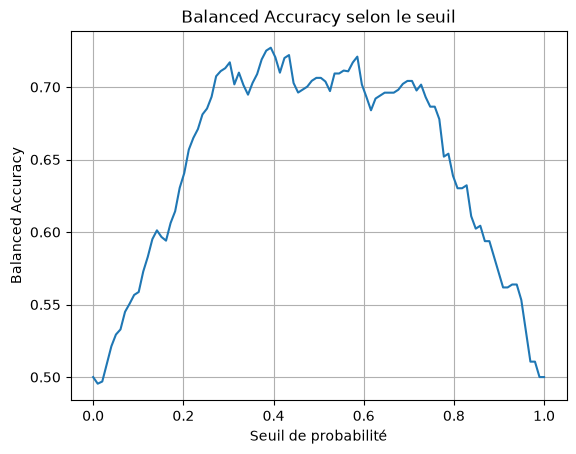

In [89]:
#========================================================================
############################  ATTENTION  ################################
#bien prendre les bonne donner d'entrainement si le meilleur model change
#=========================================================================

VISUALISATINONMODEL_TO_VIEW = 4
MODEL = "Logistic Regression"

final_pipeline = df_model_score[(df_model_score["generation"]==4) & (df_model_score["model"]==MODEL)]["pipeline"].iloc[0]

X_train_final, X_test_final, y_train_final, y_testfinal  = X_train_4, X_test_4, y_train_4, y_test_4 

final_pipeline.fit(X_train_final, y_train_final) 

# --- Récupération des probabilités (pas les classes 0/1) ---
y_scores = final_pipeline.predict_proba(X_test_4)[:, 1]  # proba de la classe positive (démission)

thresholds = np.linspace(0, 1, 100)
balanced_acc_scores = []

for threshold in thresholds:
    # on binarise les probabilités selon le seuil testé
    y_pred_at_threshold = (y_scores >= threshold).astype(int)
    score = balanced_accuracy_score(y_test_4, y_pred_at_threshold)
    balanced_acc_scores.append(score)

plt.plot(thresholds, balanced_acc_scores)
plt.xlabel("Seuil de probabilité")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy selon le seuil")
plt.grid(True)
plt.show()

### <p style="background-color:#2980B9; color:#FFFFFF; padding:10px 15px; border-radius:5px; font-size:18px; font-weight:bold;">6.2 - Visualisation SHAP</p>

In [90]:
# 1. Entraîner le pipeline final sur tout le train_val

# 2. Extraire le préprocesseur et le modèle séparément du pipeline entraîné
fitted_preprocessor = final_pipeline.named_steps['preprocessor']
fitted_model = final_pipeline.named_steps['classifier']

# 3. Transformer les données AVANT de les passer à SHAP
# C'est l'étape cruciale : SHAP doit voir les données comme le modèle les voit
X_test_transformed = fitted_preprocessor.transform(X_test_final)

# 4. Récupérer les noms de features après transformation
# OneHotEncoder change les noms de colonnes (ex: "departement" devient "departement_RH", "departement_IT"...)
feature_names = fitted_preprocessor.get_feature_names_out()

# Convertir en DataFrame pour garder les noms de colonnes (SHAP les affiche mieux ainsi)

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Construire la donnée finale telle que le modèle la voit réellement (avec ou sans scaler)
if 'scaler' in final_pipeline.named_steps:
    fitted_scaler = final_pipeline.named_steps['scaler']
    X_test_for_model = fitted_scaler.transform(X_test_transformed_df.values)
    X_test_for_model = pd.DataFrame(X_test_for_model, columns=feature_names)
else:
    X_test_for_model = X_test_transformed_df

# shap.Explainer détecte automatiquement le type de modèle et choisit
# TreeExplainer, LinearExplainer, ou un fallback approprié
# Créer un masker explicite avec max_samples fixé
masker = shap.maskers.Independent(X_test_for_model, max_samples=X_test_for_model.shape[0])

explainer = shap.Explainer(fitted_model, masker)
shap_values = explainer(X_test_for_model)

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">6.2.1 - Graphique Beeswarm</p>

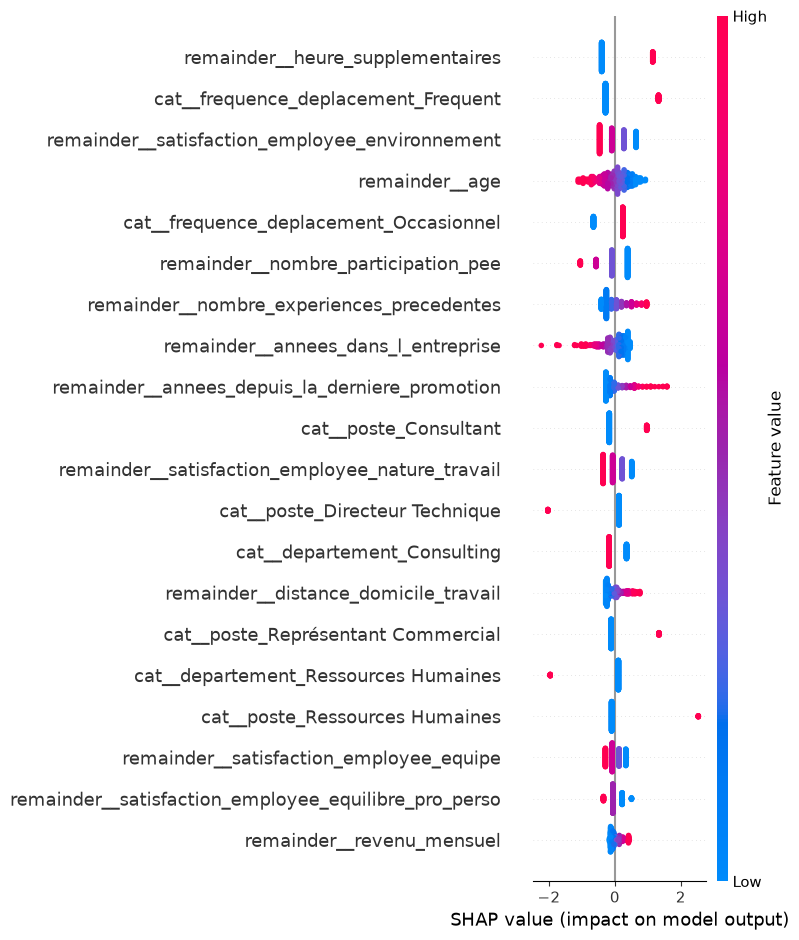

In [91]:
shap.summary_plot(shap_values, X_test_transformed_df, show=False)
plt.tight_layout()
plt.show()

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">6.2.2 - Feature importance plot </p>

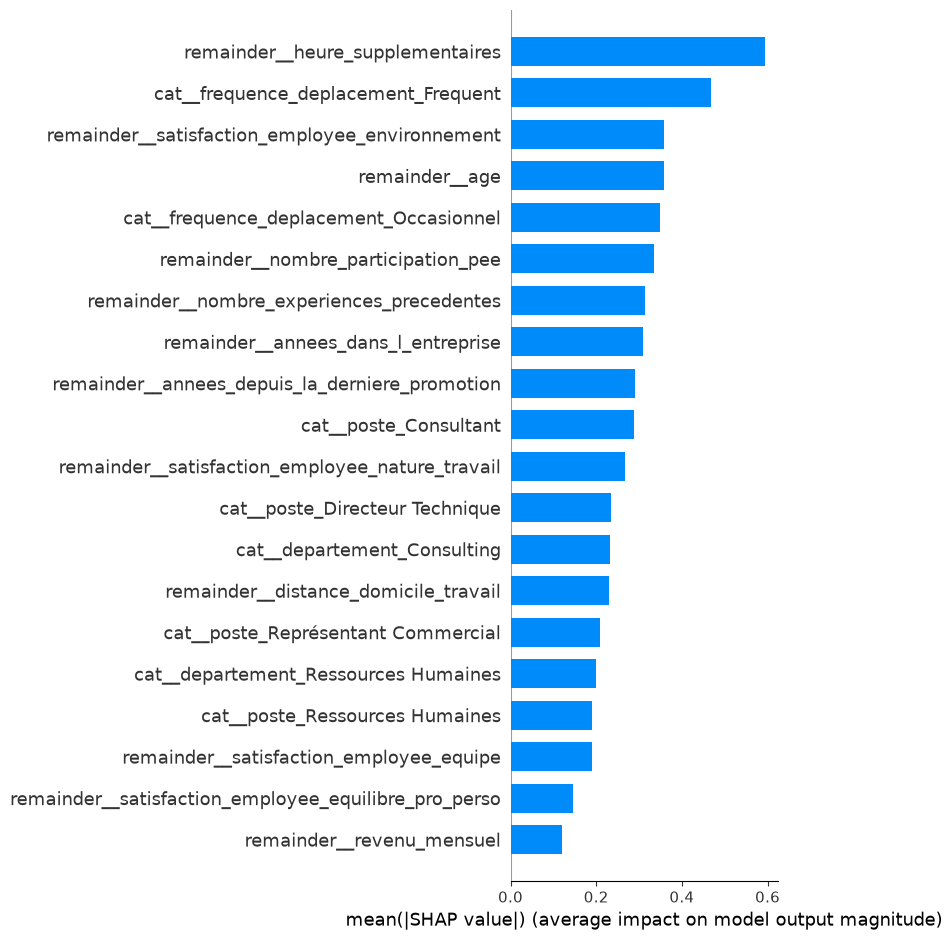

In [92]:
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">6.2.3 - Liste des Features importance </p>

In [95]:
#prendre les features au dessus d'un certain seuil

# Mean absolute SHAP value per column (= global importance per feature)
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# Link values to column names
feature_importance = pd.Series(mean_abs_shap, index=X_test_transformed_df.columns)

# Filter by your threshold
threshold = 0.15
important_features = feature_importance[feature_importance >= threshold].index.tolist()

print(important_features)

['cat__departement_Consulting', 'cat__departement_Ressources Humaines', 'cat__poste_Consultant', 'cat__poste_Directeur Technique', 'cat__poste_Représentant Commercial', 'cat__poste_Ressources Humaines', 'cat__frequence_deplacement_Frequent', 'cat__frequence_deplacement_Occasionnel', 'remainder__age', 'remainder__nombre_experiences_precedentes', 'remainder__annees_dans_l_entreprise', 'remainder__satisfaction_employee_environnement', 'remainder__satisfaction_employee_nature_travail', 'remainder__satisfaction_employee_equipe', 'remainder__heure_supplementaires', 'remainder__nombre_participation_pee', 'remainder__distance_domicile_travail', 'remainder__annees_depuis_la_derniere_promotion']


In [96]:
#recuperer les véritable nom des feature
cleaned_names = []
for name in important_features:
    if name.startswith("cat"):
        # remove everything before the first underscore AND after the last underscore
        first_split = name.split("__", 1)[1]      # drop "cat"
        variable_name = first_split.rsplit("_", 1)[0]  # drop modality after last "_"
    else:
        # remove only the prefix before the first underscore (i.e. "remainder")
        variable_name = name.split("__", 1)[1]

    cleaned_names.append(variable_name)

# dédoublonnage en conservant l'ordre d'apparition
unique_names = list(dict.fromkeys(cleaned_names))

display(unique_names)
print("Nombre de feature dont catégoriel : ",len(important_features))
print("Nombre de feature de base : ",len(unique_names))

['departement',
 'poste',
 'frequence_deplacement',
 'age',
 'nombre_experiences_precedentes',
 'annees_dans_l_entreprise',
 'satisfaction_employee_environnement',
 'satisfaction_employee_nature_travail',
 'satisfaction_employee_equipe',
 'heure_supplementaires',
 'nombre_participation_pee',
 'distance_domicile_travail',
 'annees_depuis_la_derniere_promotion']

Nombre de feature dont catégoriel :  18
Nombre de feature de base :  13


#### <p style="background-color:#AED6F1; color:#1A5276; padding:8px 15px; border-radius:4px; font-size:15px; font-weight:bold;">6.2.4 - SHAP dependence plots  </p>

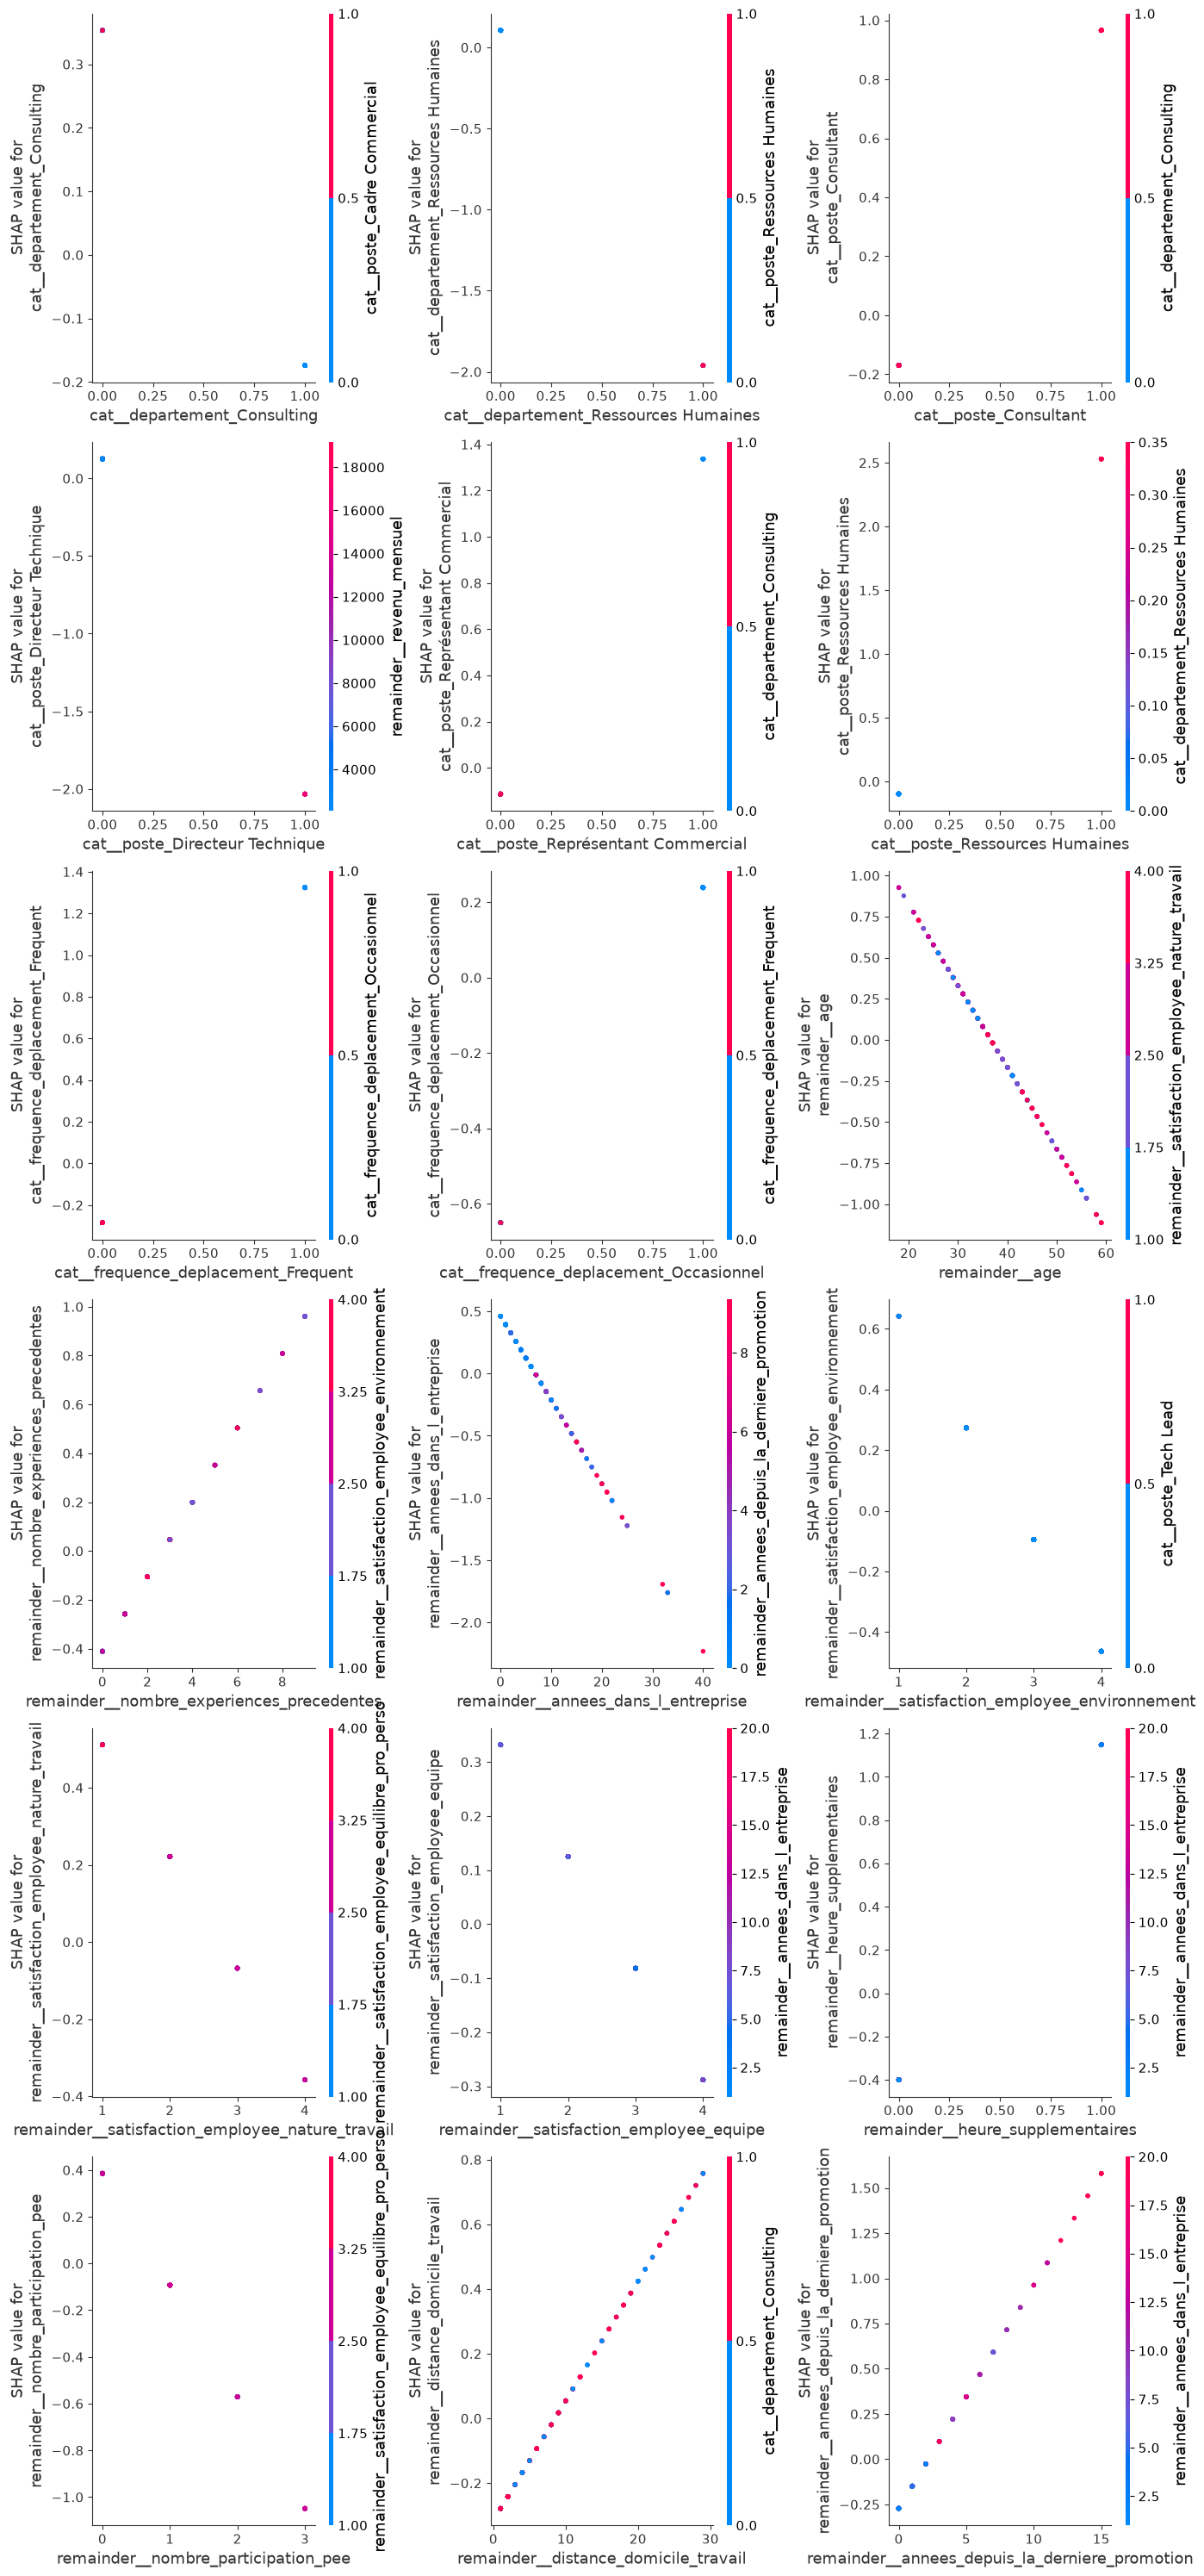

In [98]:

n_features = len(important_features)

# Create a grid of subplots: adjust nrows/ncols depending on how many features you have
n_cols = 3
n_rows = -(-n_features // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # easier to iterate even if grid is 2D

for i, feature in enumerate(important_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_test_transformed_df,
        ax=axes[i],       # key point: draw on this specific subplot
        show=False        # prevent SHAP from calling plt.show() itself
    )
   

# Hide any unused subplots if n_features is not a multiple of n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()